# Notebook 04 — Model Training & Evaluation
**Project:** Natural Gas Pipeline Risk Mapping & Incident Prediction  
**Author:** Ankita Prashant Naik  

We train Random Forest and XGBoost classifiers to predict pipeline incident severity (binary: high vs. low). Both models handle class imbalance explicitly. We compare ROC-AUC, F1, Precision, and Recall, then apply SHAP to explain model decisions.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, classification_report,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

plt.rcParams.update({'figure.dpi': 120})
PROCESSED = Path('../data/processed')
MODELS = Path('../models')
OUTPUTS = Path('../outputs')
MODELS.mkdir(exist_ok=True)
OUTPUTS.mkdir(exist_ok=True)

## 1. Load Feature Matrix

In [2]:
df = pd.read_csv(PROCESSED / 'pipeline_features.csv', low_memory=False)
print(f'Feature matrix: {df.shape}')

y = df['high_severity'].astype(int)
X = df.drop(columns=['high_severity'])

# Drop non-numeric
obj_cols = X.select_dtypes(include=['object', 'datetime64']).columns.tolist()
if obj_cols:
    print(f'Dropping non-numeric: {obj_cols}')
    X = X.drop(columns=obj_cols)

X = X.fillna(X.median(numeric_only=True))

print(f'Features: {X.shape[1]}  |  Target balance:')
print(y.value_counts().to_string())

Feature matrix: (2675, 232)
Features: 231  |  Target balance:
high_severity
1    2038
0     637


## 2. Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')
print(f'Train positive rate: {y_train.mean():.3f}')
print(f'scale_pos_weight for XGBoost: {scale_pos_weight:.2f}')

Train: 2,140  |  Test: 535
Train positive rate: 0.762
scale_pos_weight for XGBoost: 0.31


## 3. Train Random Forest

In [4]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)

print('Random Forest Results:')
print(f'  ROC-AUC : {roc_auc_score(y_test, rf_proba):.4f}')
print(f'  F1 (wtd): {f1_score(y_test, rf_pred, average="weighted"):.4f}')
print(f'  Precision: {precision_score(y_test, rf_pred, zero_division=0):.4f}')
print(f'  Recall  : {recall_score(y_test, rf_pred, zero_division=0):.4f}')
print()
print(classification_report(y_test, rf_pred, target_names=['Low', 'High']))

joblib.dump(rf, MODELS / 'random_forest_pipeline_risk.pkl')
print('Model saved → models/random_forest_pipeline_risk.pkl')

Random Forest Results:
  ROC-AUC : 0.9982
  F1 (wtd): 0.9888
  Precision: 0.9951
  Recall  : 0.9902

              precision    recall  f1-score   support

         Low       0.97      0.98      0.98       127
        High       1.00      0.99      0.99       408

    accuracy                           0.99       535
   macro avg       0.98      0.99      0.98       535
weighted avg       0.99      0.99      0.99       535

Model saved → models/random_forest_pipeline_risk.pkl


## 4. Train XGBoost

In [5]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_pred = xgb.predict(X_test)

print('XGBoost Results:')
print(f'  ROC-AUC : {roc_auc_score(y_test, xgb_proba):.4f}')
print(f'  F1 (wtd): {f1_score(y_test, xgb_pred, average="weighted"):.4f}')
print(f'  Precision: {precision_score(y_test, xgb_pred, zero_division=0):.4f}')
print(f'  Recall  : {recall_score(y_test, xgb_pred, zero_division=0):.4f}')
print()
print(classification_report(y_test, xgb_pred, target_names=['Low', 'High']))

joblib.dump(xgb, MODELS / 'xgboost_pipeline_risk.pkl')
print('Model saved → models/xgboost_pipeline_risk.pkl')

XGBoost Results:
  ROC-AUC : 0.9973
  F1 (wtd): 0.9944
  Precision: 1.0000
  Recall  : 0.9926

              precision    recall  f1-score   support

         Low       0.98      1.00      0.99       127
        High       1.00      0.99      1.00       408

    accuracy                           0.99       535
   macro avg       0.99      1.00      0.99       535
weighted avg       0.99      0.99      0.99       535

Model saved → models/xgboost_pipeline_risk.pkl


## 5. ROC-AUC Comparison

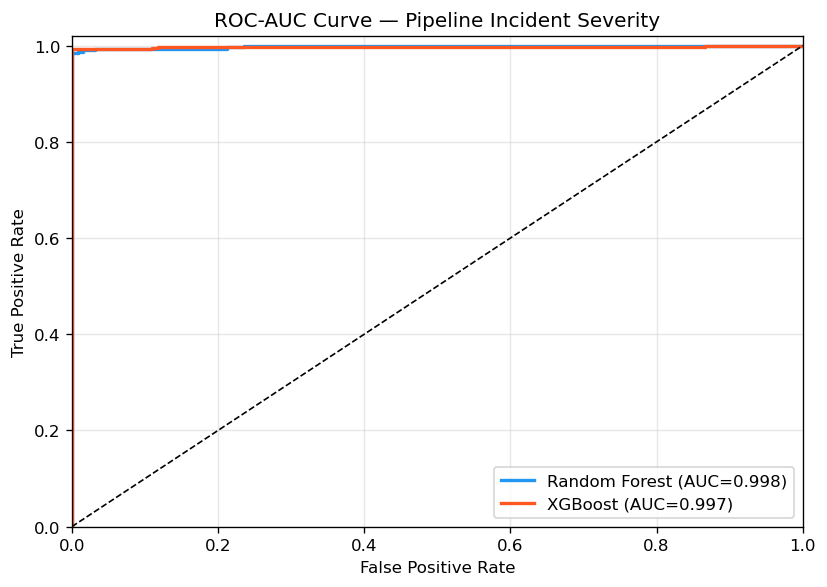

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, proba, color in [
    ('Random Forest', rf_proba, '#2196F3'),
    ('XGBoost', xgb_proba, '#FF5722')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    from sklearn.metrics import auc
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-AUC Curve — Pipeline Incident Severity')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / 'roc_curve.png', bbox_inches='tight')
plt.show()

## 6. Confusion Matrix

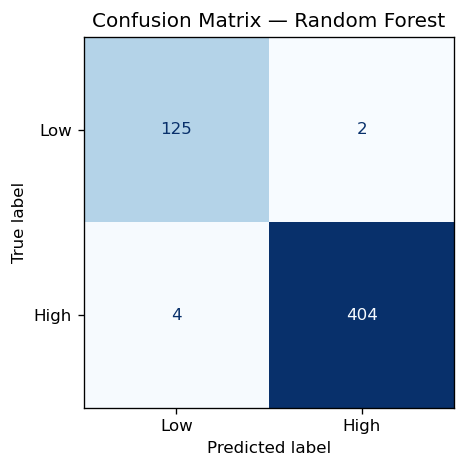

In [7]:
best_pred = rf_pred if roc_auc_score(y_test, rf_proba) >= roc_auc_score(y_test, xgb_proba) else xgb_pred
best_name = 'Random Forest' if roc_auc_score(y_test, rf_proba) >= roc_auc_score(y_test, xgb_proba) else 'XGBoost'

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Low', 'High'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.savefig(OUTPUTS / 'confusion_matrix.png', bbox_inches='tight')
plt.show()

## 7. Feature Importance (Random Forest)

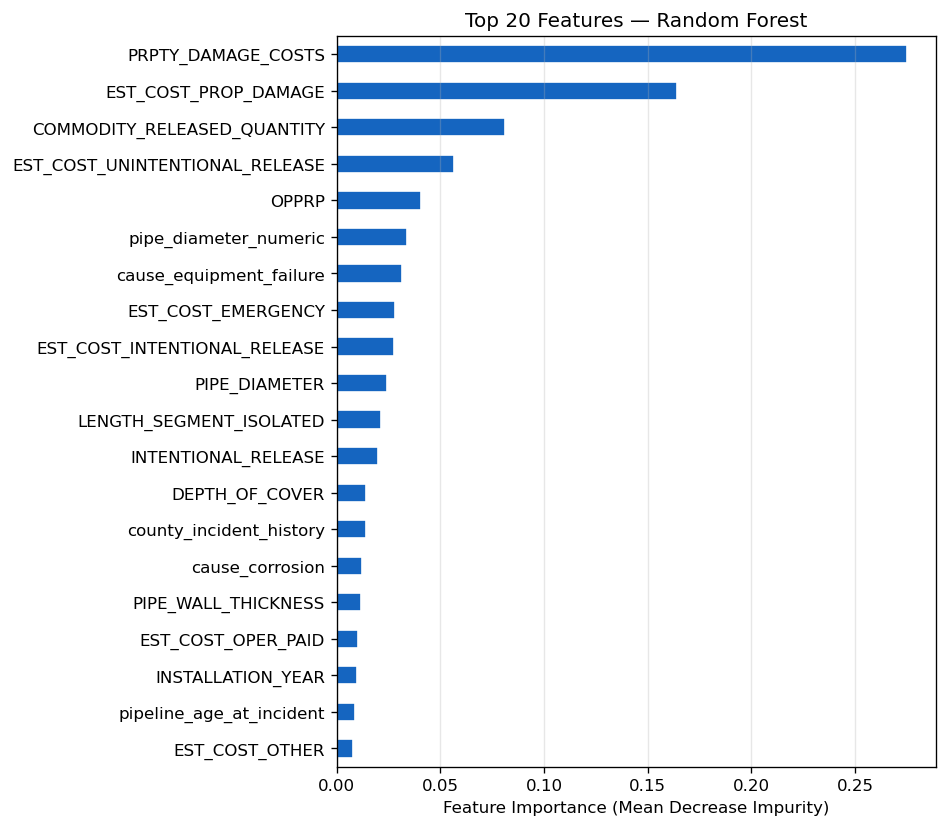

In [8]:
importances = pd.Series(rf.feature_importances_, index=X.columns).nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
importances.plot(kind='barh', ax=ax, color='#1565C0', edgecolor='white')
ax.set_xlabel('Feature Importance (Mean Decrease Impurity)')
ax.set_title('Top 20 Features — Random Forest')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / 'feature_importance.png', bbox_inches='tight')
plt.show()

## 8. SHAP Explainability

Computing SHAP values...


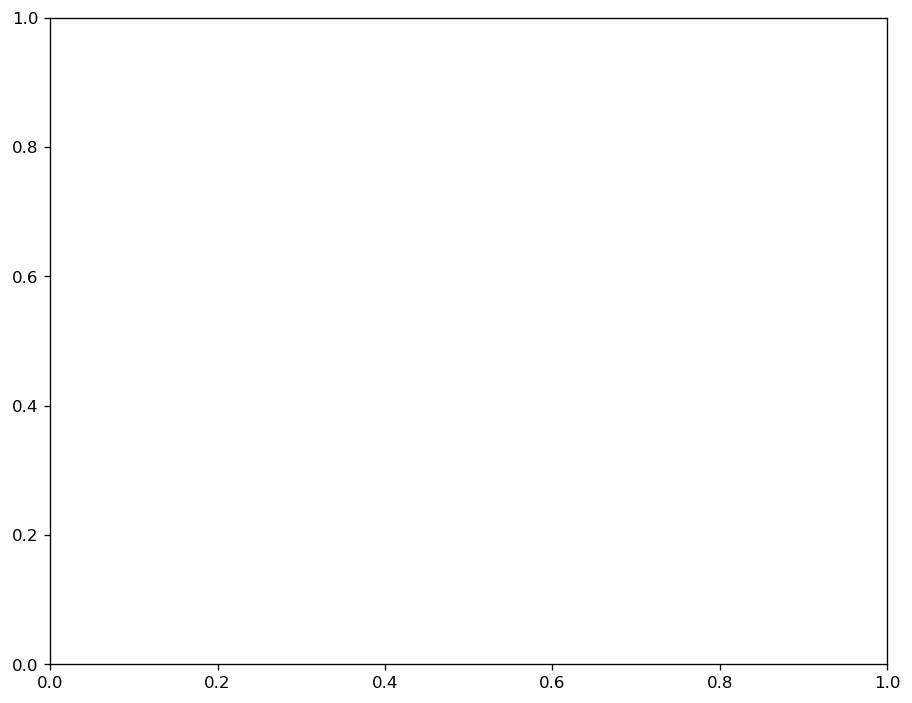

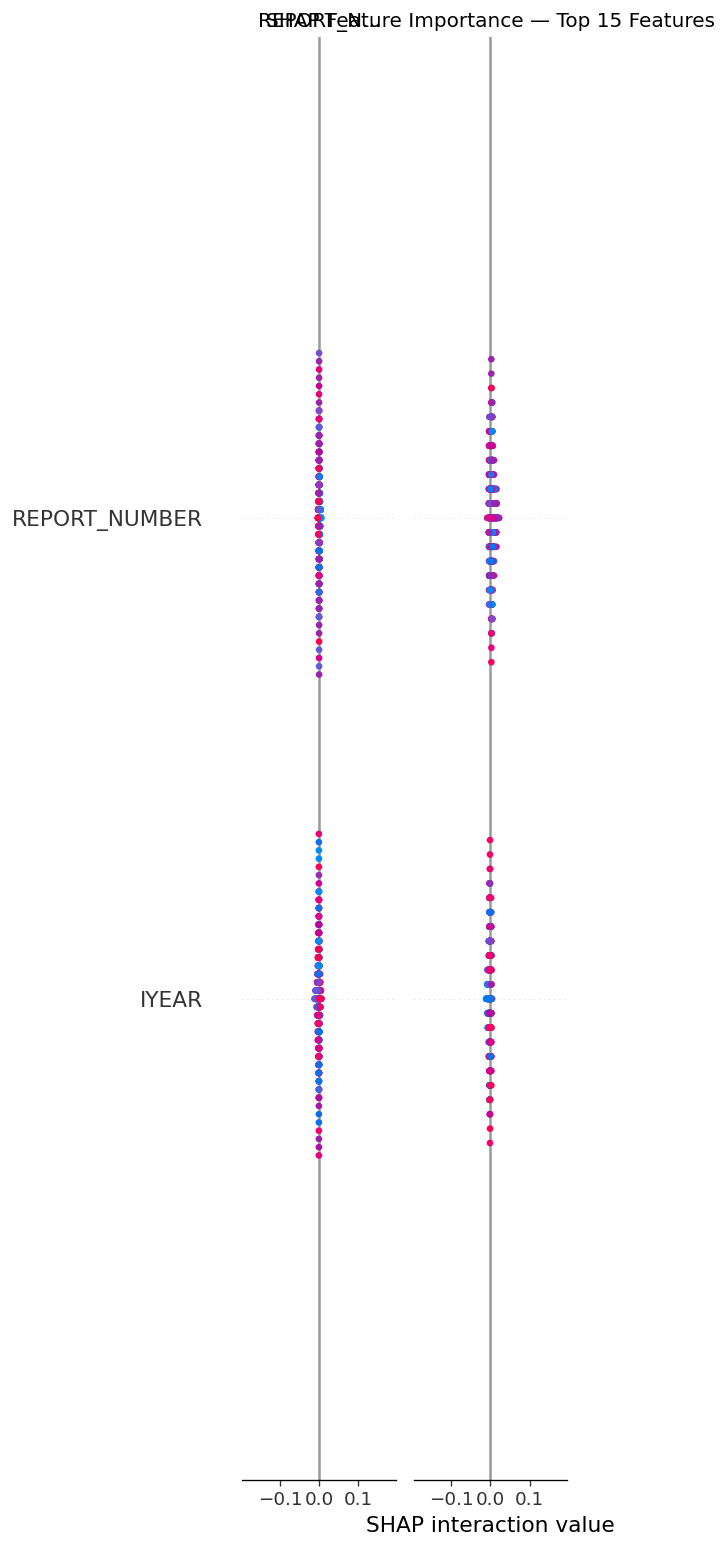

In [9]:
print('Computing SHAP values...')
explainer = shap.TreeExplainer(rf)
sample = X_test.sample(min(500, len(X_test)), random_state=42)
shap_values = explainer.shap_values(sample)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(sv, sample, max_display=15, show=False)
plt.title('SHAP Feature Importance — Top 15 Features')
plt.tight_layout()
plt.savefig(OUTPUTS / 'shap_summary.png', bbox_inches='tight')
plt.show()

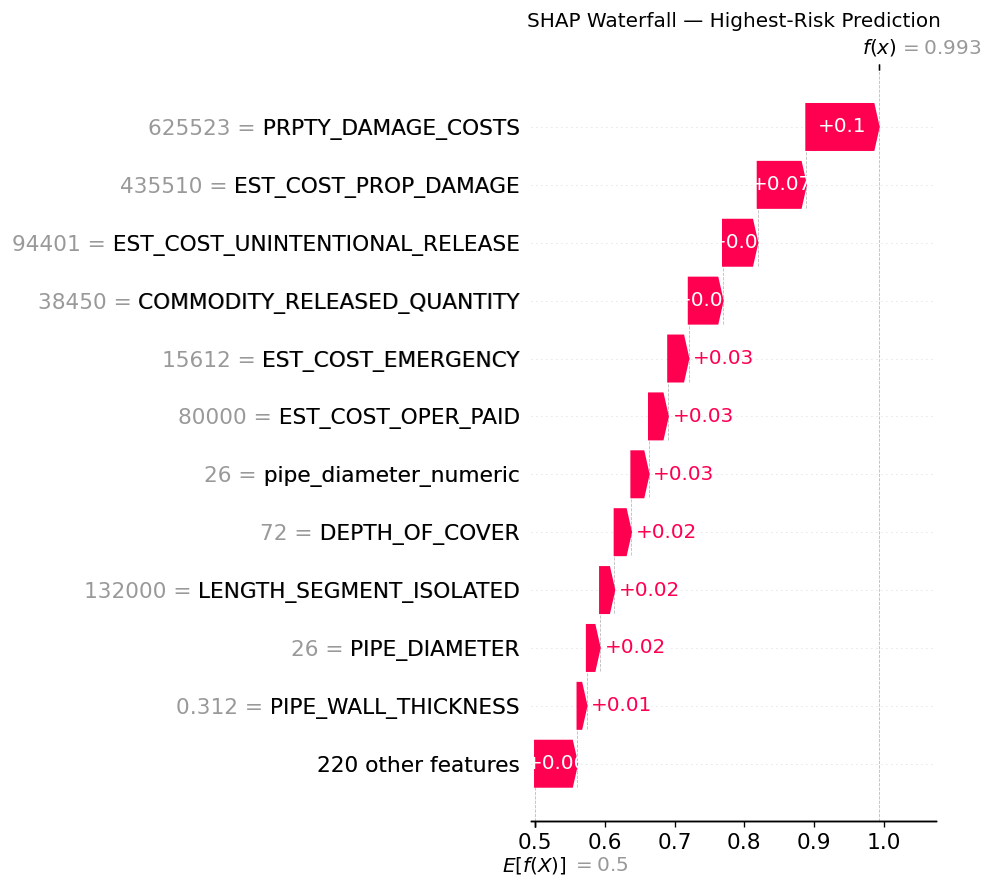

In [10]:
# Waterfall for a single high-risk prediction
shap_exp = explainer(sample)
# For binary RF, shap_exp.values has shape (n_samples, n_features, n_classes)
# Select class-1 slice for the highest-risk prediction
if shap_exp.values.ndim == 3:
    sv_class1 = shap_exp[:, :, 1]
    high_risk_idx = int(np.argmax(sv_class1.values[:, :].sum(axis=1)))
    sv_to_plot = sv_class1[high_risk_idx]
else:
    high_risk_idx = int(np.argmax(shap_exp.values.sum(axis=1)))
    sv_to_plot = shap_exp[high_risk_idx]

fig, ax = plt.subplots(figsize=(9, 5))
shap.plots.waterfall(sv_to_plot, max_display=12, show=False)
plt.title('SHAP Waterfall — Highest-Risk Prediction')
plt.tight_layout()
plt.savefig(OUTPUTS / 'shap_waterfall.png', bbox_inches='tight')
plt.show()


## 9. Save Risk Scores for Map

In [11]:
test_results = X_test.copy()
test_results['high_severity_actual'] = y_test.values
test_results['rf_risk_score'] = rf_proba
test_results['xgb_risk_score'] = xgb_proba
test_results['risk_score'] = rf_proba  # use RF as primary
test_results['risk_label'] = pd.cut(
    rf_proba, bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

out = PROCESSED / 'risk_scores.csv'
test_results.to_csv(out, index=False)
print(f'Risk scores saved → {out}')
print(test_results['risk_label'].value_counts().to_string())

Risk scores saved → ../data/processed/risk_scores.csv
risk_label
High      395
Low       104
Medium     36
